In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
np.random.seed(1)

### Simple Linear Regression

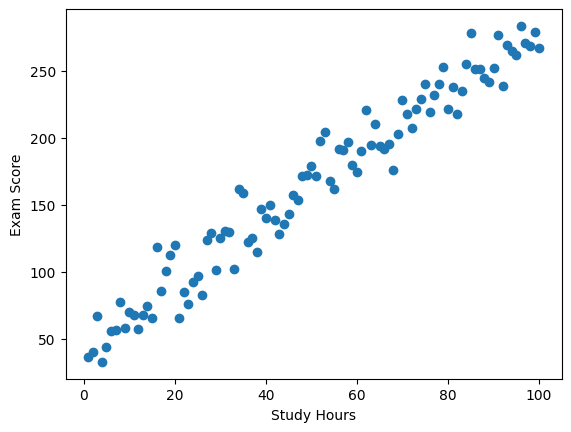

44.89068663770517
[2.38330073]
[ 47.27398737  49.6572881   52.04058883  54.42388956  56.8071903
  59.19049103  61.57379176  63.95709249  66.34039322  68.72369395
  71.10699468  73.49029542  75.87359615  78.25689688  80.64019761
  83.02349834  85.40679907  87.79009981  90.17340054  92.55670127
  94.940002    97.32330273  99.70660346 102.08990419 104.47320493
 106.85650566 109.23980639 111.62310712 114.00640785 116.38970858
 118.77300931 121.15631005 123.53961078 125.92291151 128.30621224
 130.68951297 133.0728137  135.45611444 137.83941517 140.2227159
 142.60601663 144.98931736 147.37261809 149.75591882 152.13921956
 154.52252029 156.90582102 159.28912175 161.67242248 164.05572321
 166.43902395 168.82232468 171.20562541 173.58892614 175.97222687
 178.3555276  180.73882833 183.12212907 185.5054298  187.88873053
 190.27203126 192.65533199 195.03863272 197.42193346 199.80523419
 202.18853492 204.57183565 206.95513638 209.33843711 211.72173784
 214.10503858 216.48833931 218.87164004 221.254

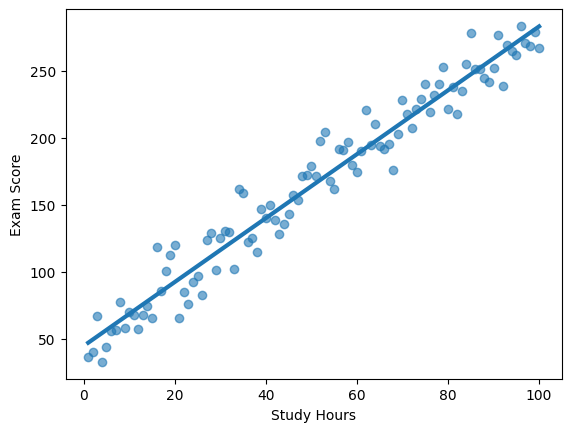

In [26]:
# Building a regression model.

hours = np.arange(1, 101)

scores = (
    40
    + 2.5*hours
    + np.random.normal(loc=0, scale=15, size=100)
)

# Visualizing.

plt.scatter(
    hours,
    scores
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

# Building the model.

model = LinearRegression()

X = hours.reshape(-1, 1)

model.fit(X, scores)

# Extracting coefficients.

print(model.intercept_)
print(model.coef_)

# Making predictions.

predictions = model.predict(X)

print(predictions)

# Computing R2 (R**2).

r_squared = model.score(X, scores)

print(r_squared) # R2 = 0: 0%, R2 = 1: 100%.

# Visualizing the regression line.

plt.scatter(hours, scores, alpha=0.6)

plt.plot(hours, predictions, linewidth=3)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.show()

In [25]:
# Using statsmodels.

# Adding intercept.

X = sm.add_constant(hours)

# Fiting the model.

model = sm.OLS(
    scores,
    X
).fit()

# Getting summary.

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1917.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           3.77e-66
Time:                        16:14:20   Log-Likelihood:                -422.06
No. Observations:                 100   AIC:                             848.1
Df Residuals:                      98   BIC:                             853.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.6753      3.353     11.236      0.0

### Multiple Regression

In [20]:
# Simulating data.

participants = 200

hours = np.random.normal(loc=10, scale=3, size=participants)

iq = np.random.normal(loc=100, scale=15, size=participants)

sleep = np.random.normal(loc=7, scale=1, size=participants)

# Creating outcome.

score = (
    20
    + 2*hours
    + 0.5*iq
    + 3*sleep
    + np.random.normal(loc=0, scale=10, size=participants) # Errors.
)

# Building predictor matrix.

df = pd.DataFrame({
    "hours": hours,
    "iq": iq,
    "sleep": sleep,
    "score": score
})

print(df.head())

# Building multiple regression model.

# Creating prodictors.

X = df[["hours", "iq", "sleep"]]

# Adding intercept.

X = sm.add_constant(X)

y = df["score"]

# Fitting the model.

model = sm.OLS(y, X).fit()

print(model.summary())

      hours          iq     sleep       score
0  7.889815  116.259280  6.546497  111.450716
1  7.226471   99.803569  6.179095  108.053180
2  8.198648   91.079856  7.940219   99.164617
3  7.262240   81.229139  5.588707   86.349597
4  9.954998   88.459246  7.884148  108.610564
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     87.48
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           5.82e-36
Time:                        16:13:49   Log-Likelihood:                -731.20
No. Observations:                 200   AIC:                             1470.
Df Residuals:                     196   BIC:                             1484.
Df Model:                           3                                         
Covariance Ty

### Regression Diagnostics

#### Residuals

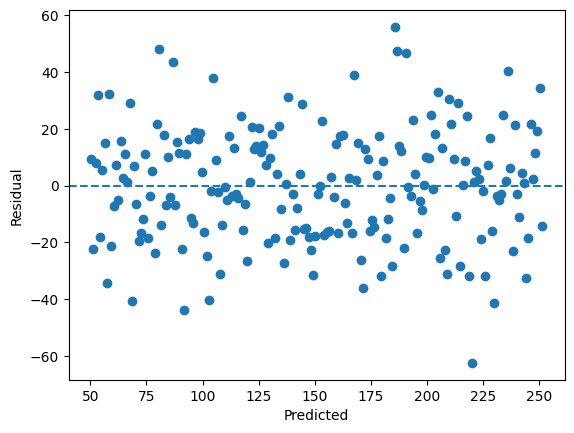

In [19]:
# Simulating data.

x = np.linspace(0, 100, 200)

y = (
    50
    + 2*x
    + np.random.normal(loc=0, scale=20, size=200)
)

# Fitting regression.

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

# Extracting residuals.

residuals = model.resid

predicted = model.fittedvalues

# Visualizing residuals.

plt.scatter(predicted, residuals)

plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.show() # Note: random cloud is good, any pattern in bad.

#### Heteroscedasticity

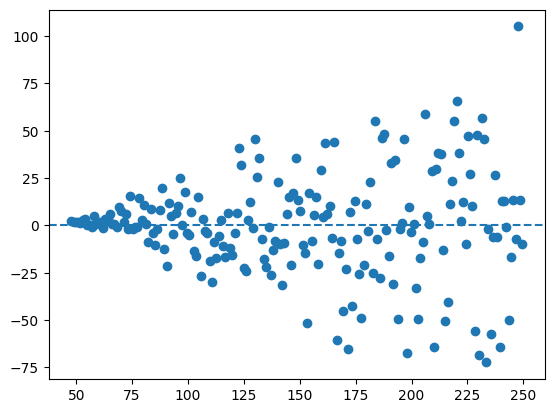

In [18]:
# Simulating heteroscedastic data.

x = np.linspace(0, 100, 200)

noise = np.random.normal(0, x/2)

y = 50 + 2*x + noise

# Fitting the model.

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

# Visualizing residuals.

plt.scatter(model.fittedvalues,  model.resid)

plt.axhline(0, linestyle="--")

plt.show() # Funnel shape.

In [14]:
# Detecting heteroscedasticity.

test = het_breuschpagan(
    model.resid,
    model.model.exog
)

print(test)

(np.float64(39.02269133938019), np.float64(4.1890808024764064e-10), np.float64(47.997403792398124), np.float64(5.849330957556985e-11))


Output of het_breuschpagan: LM statistic, LM p-value, F statistic, F p-value

Note: evidence for heteroscedasticity if p < .05.

What To Do If Heteroscedasticity Exists? Several options:
1. Transform variables. (log, sqrt)
2. Use robust standard errors. (model.get_robustcov_results())
3. Use alternative models.

#### Influence Points

the largest values: [46  0 47 44 50]


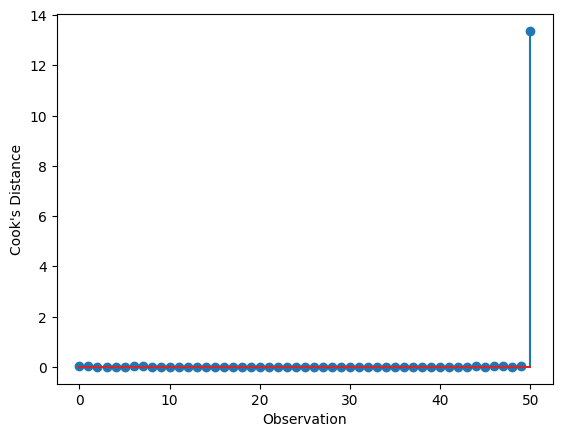

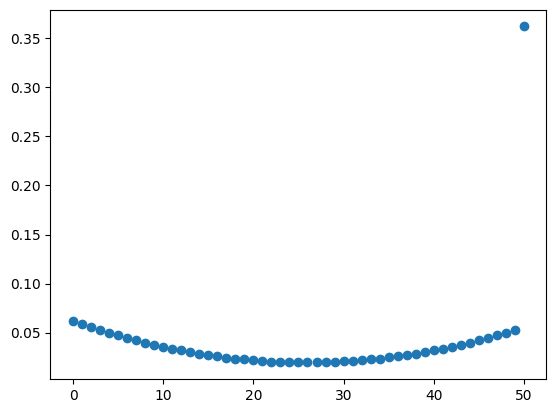

In [17]:
# Detecting influential observations.

x = np.arange(50)

y = 3*x + np.random.normal(loc=0, scale=5, size=50)

# Adding influential point.

x = np.append(x, 100)

y = np.append(y, 500)

# Fitting the model.

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

# Computing influence.

influence = model.get_influence()

# Cook's distance. (The most common influence measure.)

cooks_d = influence.cooks_distance[0]

# Inspecting the largest values.

largest = np.argsort(cooks_d)[-5:]

print("the largest values:", largest)

# Visualizing.

plt.stem(cooks_d)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")

plt.show()

# Computing leverag values.

leverage = influence.hat_matrix_diag

# Visualizing.

plt.scatter(
    range(len(leverage)),
    leverage
)

plt.show()

#### Complete Diagnostic Workflow
- Step 0: fitting a regression.
    > model = sm.OLS(y, X).fit()
- Step 1: model summary to looking at coefficients.
    > model.summary()
- Step 2: finding residuals.
    > residuals = model.resid
- Step 3: visualizing residual. Looking for any patterns (curvature, funnels, clusters, etc.).
    > plt.scatter(model.fittedvalues, residuals)
- Step 4: normality assessment.
    > from scipy.stats import shapiro

    > shapiro(residuals)
- Step 5: Breusch-Pagan.
    > het_breuschpagan(residuals, model.model.exog)
- Step 6: influence diagnostics. Checking Cook's distance and Leverage values.
    > model.get_influence()



### Multicollinearity

In [28]:
# Simulating a healthy dataset.

participants = 300

hours = np.random.normal(loc=10, scale=3, size=participants)

sleep = np.random.normal(loc=7, scale=1, size= participants)

# Creating outcome.

score = (
    50
    + 4*hours
    + 3*sleep
    + np.random.normal(loc=0, scale=10, size=participants)
)

# Fitting the model.

X = pd.DataFrame({
    "hours": hours,
    "sleep": sleep
})

X = sm.add_constant(X)

model = sm.OLS(score, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     271.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           9.56e-68
Time:                        16:38:32   Log-Likelihood:                -1124.3
No. Observations:                 300   AIC:                             2255.
Df Residuals:                     297   BIC:                             2266.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.9101      5.031      9.324      0.0

In [31]:
# Create collinear predictors.

minutes = (
    hours * 60
    + np.random.normal(loc=0, scale=5, size=participants)
)

# Checking correlation.

print(np.corrcoef(hours, minutes))

# Building collinear model.

X = pd.DataFrame({
    "hours": hours,
    "minutes": minutes
})

X = sm.add_constant(X)

model = sm.OLS(score, X).fit()

print(model.summary())

# Creating a correlation matrix.

df = pd.DataFrame({
    "hours": hours,
    "minutes": minutes,
    "sleep": sleep
})

print("\nCorrelation matrix:\n", df.corr())

[[1.         0.99966926]
 [0.99966926 1.        ]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     243.7
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.36e-63
Time:                        16:42:45   Log-Likelihood:                -1134.5
No. Observations:                 300   AIC:                             2275.
Df Residuals:                     297   BIC:                             2286.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

#### Variance Inflation Factor (VIF)
Note: no multicollinearity creates small inflation. High multicollinearity creates large inflation.

In [33]:
# Building predictor matrix.

X = pd.DataFrame({
    "hours": hours,
    "minutes": minutes,
    "sleep": sleep
})

# Computing VIF.

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif)

  Variable           VIF
0    hours  16546.310132
1  minutes  16606.345392
2    sleep      9.742970
